In [16]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt
import matplotlib
import seaborn as sns
import copy
import pickle
import warnings
warnings.filterwarnings('ignore')
import shap
from models import *
from utilities import *

In [18]:
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42 
matplotlib.rc('font', family='sans-serif') 
matplotlib.rc('font', serif='Helvetica Neue') 

In [19]:
##########################################################################################################

In [20]:
import tensorflow as tf
tf.compat.v1.disable_v2_behavior()

In [21]:
shap.explainers._deep.deep_tf.op_handlers["AddV2"] = shap.explainers._deep.deep_tf.passthrough 
shap.explainers._deep.deep_tf.op_handlers["FusedBatchNormV3"] = shap.explainers._deep.deep_tf.passthrough

In [22]:
################### data import ###############

In [23]:
data_dir = '../results/data/'
data_copy = pd.read_pickle(data_dir + 'LSTM_processed_data_dy_filter.pkl')
ba_copy = pd.read_pickle(data_dir + 'LSTM_processed_data_ba_filter.pkl')
data_copy['Id_encoded'], uniques = pd.factorize(data_copy['SCCRIP_ID'])
mapping_dict = {value: index for index, value in enumerate(uniques)}

In [24]:
ba_copy['Id_encoded'] = ba_copy['SCCRIP_ID'].map(mapping_dict)
ba_copy = ba_copy[ba_copy['Id_encoded'].notna()]
ba_copy = ba_copy.drop_duplicates(subset='SCCRIP_ID', keep='last')
ba_copy.drop('SCCRIP_ID', inplace=True, axis=1)

In [25]:
ba_copy = ba_copy.fillna(0)
data_copy = data_copy.fillna(0)

In [26]:
with open(data_dir +  'SCCRIP_ID_dict.pkl', 'wb') as f:
    pickle.dump(mapping_dict, f)

In [27]:
len(data_copy.SCCRIP_ID.unique())

1267

In [28]:
################ data process ##################

In [29]:
seq_length = 5

In [36]:
ys = {'pred':[],
     'test':[]}
paras = {'ls':[],
         'dt':[],
         'r2':[]}

# for i in range(20):
sequences, seq_ba, labels, date,  y_target = create_dataset(data_copy, ba_copy, seq_length, mapping_dict)
sequences_copy, seq_ba_copy, labels_copy, date_copy, y_target_copy = shuffle_dataset(sequences, seq_ba, labels, date, y_target)
X, y, X_bg, dt, ls, seq_map = create_sequences_with_background(sequences_copy, labels_copy, seq_ba_copy, date_copy,y_target_copy, seq_length)
X_normalized, X_bg_normalized = normalize_X(X, X_bg)

combined_model = CombinedLSTMModel(seq_length=seq_length, n_features=868, bg_features=44, summary=False)
i = 0
while i < 30:
    print (i)
    idx = np.random.permutation(X_normalized.shape[-1])
    X_normalized = X_normalized[:, :, idx]

    idx2 = np.random.permutation(X_bg_normalized.shape[-1])
    X_bg_normalized = X_bg_normalized[:, :, idx2]
    
    
    (X_train,X_val,X_test,
            X_bg_train,X_bg_val,X_bg_test,
            dt_train, dt_val, dt_test, 
            y_train,y_val,y_test,
            ls_train, ls_val, ls_test,
            seq_map_train, seq_map_val, seq_map_test) = split_dataset(X_normalized, X_bg_normalized,dt, y, ls, seq_map, random_state=100)

     # combined_model = CombinedLSTMModel(seq_length=seq_length, n_features=int(X_train.shape[2]), bg_features=int(X_bg_train.shape[2]), summary=False)
    # Train the model
    history = combined_model.train(
        X_train, X_bg_train, dt_train, y_train,
        X_val,   X_bg_val,   dt_val,   y_val,
        epochs=20, batch_size=64,
        checkpoint_path="../results/models/mix_best_5x.h5"
    )
    
    y_pred = combined_model.predict(X_test, X_bg_test, dt_test)
    r2 = r2_score(y_test.flatten(), y_pred.flatten())
    if r2 > 0:
        ys['pred'].append(copy.deepcopy(y_pred))
        ys['test'].append(copy.deepcopy(y_test))
    
        paras['ls'].append(copy.deepcopy(ls_test))
        paras['dt'].append(copy.deepcopy(dt_test))
        paras['r2'].append(copy.deepcopy(r2))  
        i += 1

0
Train on 18582 samples, validate on 4655 samples


2025-09-18 16:36:32.343096: W tensorflow/c/c_api.cc:305] Operation '{name:'dense_16_34/bias/Assign' id:34368 op device:{requested: '', assigned: ''} def:{{{node dense_16_34/bias/Assign}} = AssignVariableOp[_has_manual_control_dependencies=true, dtype=DT_FLOAT, validate_shape=false](dense_16_34/bias, dense_16_34/bias/Initializer/zeros)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.


Epoch 1/20


2025-09-18 16:36:36.183397: W tensorflow/c/c_api.cc:305] Operation '{name:'loss_34/mul' id:34438 op device:{requested: '', assigned: ''} def:{{{node loss_34/mul}} = Mul[T=DT_FLOAT, _has_manual_control_dependencies=true](loss_34/mul/x, loss_34/relu_out_loss/value)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.



Epoch 1: val_loss improved from inf to 19.20792, saving model to ../results/models/mix_best_5x.h5
Epoch 2/20

Epoch 2: val_loss improved from 19.20792 to 15.07124, saving model to ../results/models/mix_best_5x.h5
Epoch 3/20

Epoch 3: val_loss improved from 15.07124 to 15.01265, saving model to ../results/models/mix_best_5x.h5
Epoch 4/20

Epoch 4: val_loss improved from 15.01265 to 12.54239, saving model to ../results/models/mix_best_5x.h5
Epoch 5/20

Epoch 5: val_loss improved from 12.54239 to 12.39092, saving model to ../results/models/mix_best_5x.h5
Epoch 6/20

Epoch 6: val_loss improved from 12.39092 to 12.20286, saving model to ../results/models/mix_best_5x.h5
Epoch 7/20

Epoch 7: val_loss did not improve from 12.20286
Epoch 8/20

Epoch 8: val_loss did not improve from 12.20286
Epoch 9/20

Epoch 9: val_loss did not improve from 12.20286
Epoch 10/20

Epoch 10: val_loss did not improve from 12.20286
Epoch 11/20

Epoch 11: val_loss did not improve from 12.20286
Epoch 12/20

Epoch 12:

...

2025-09-18 17:11:05.596661: W tensorflow/c/c_api.cc:305] Operation '{name:'loss_63/mul' id:64104 op device:{requested: '', assigned: ''} def:{{{node loss_63/mul}} = Mul[T=DT_FLOAT, _has_manual_control_dependencies=true](loss_63/mul/x, loss_63/relu_out_loss/value)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.



Epoch 1: val_loss improved from inf to 22.21908, saving model to ../results/models/mix_best_5x.h5
Epoch 2/20

Epoch 2: val_loss improved from 22.21908 to 19.24384, saving model to ../results/models/mix_best_5x.h5
Epoch 3/20

Epoch 3: val_loss improved from 19.24384 to 16.94858, saving model to ../results/models/mix_best_5x.h5
Epoch 4/20

Epoch 4: val_loss improved from 16.94858 to 16.47255, saving model to ../results/models/mix_best_5x.h5
Epoch 5/20

Epoch 5: val_loss improved from 16.47255 to 16.28979, saving model to ../results/models/mix_best_5x.h5
Epoch 6/20

Epoch 6: val_loss improved from 16.28979 to 16.18208, saving model to ../results/models/mix_best_5x.h5
Epoch 7/20

Epoch 7: val_loss did not improve from 16.18208
Epoch 8/20

Epoch 8: val_loss improved from 16.18208 to 15.79314, saving model to ../results/models/mix_best_5x.h5
Epoch 9/20

Epoch 9: val_loss did not improve from 15.79314
Epoch 10/20

Epoch 10: val_loss did not improve from 15.79314
Epoch 11/20

Epoch 11: val_lo

2025-09-18 17:12:10.390288: W tensorflow/c/c_api.cc:305] Operation '{name:'dense_16_64/bias/Assign' id:65014 op device:{requested: '', assigned: ''} def:{{{node dense_16_64/bias/Assign}} = AssignVariableOp[_has_manual_control_dependencies=true, dtype=DT_FLOAT, validate_shape=false](dense_16_64/bias, dense_16_64/bias/Initializer/zeros)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
2025-09-18 17:12:14.779328: W tensorflow/c/c_api.cc:305] Operation '{name:'dense_16_64/kernel/v/Assign' id:65268 op device:{requested: '', assigned: ''} def:{{{node dense_16_64/kernel/v/Assign}} = AssignVariableOp[_has_manual_control_dependencies=true, dtype=DT_FLOAT, validate_shape=false](dense_16_64/kernel/v, dense_16_64/kernel/v/Initializer/zeros)}}' was changed by setting attribute after it was run by a session. This mutation will have no eff

Best model loaded from: ../results/models/mix_best_5x.h5


2025-09-18 17:12:19.131303: W tensorflow/c/c_api.cc:305] Operation '{name:'relu_out_64/Relu' id:65040 op device:{requested: '', assigned: ''} def:{{{node relu_out_64/Relu}} = Relu[T=DT_FLOAT, _has_manual_control_dependencies=true](dense_out_64/BiasAdd)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.


In [37]:
import pickle, gzip
from pathlib import Path

def save_y_and_params(y_dict, params, out_path, compress=True):
    """
    y_dict: e.g. {"train": y_train, "val": y_val, "test": y_test}
    params: dict of hyperparameters/config
    out_path: path to .pkl or .pkl.gz
    """
    payload = {"y": y_dict, "params": params}
    Path(out_path).parent.mkdir(parents=True, exist_ok=True)
    opener = gzip.open if compress else open
    with opener(out_path, "wb") as f:
        pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)

def load_y_and_params(path, compressed=True):
    opener = gzip.open if compressed else open
    with opener(path, "rb") as f:
        payload = pickle.load(f)
    return payload["y"], payload["params"]

# save_y_and_params(ys, paras, '../results/data/mix/shuffle.pkl', compress=False)

In [38]:
_, paras = load_y_and_params('../results/data/mix/shuffle.pkl',compress=False)

[0.8856131434440613,
 0.8807870149612427,
 0.8853265047073364,
 0.8802473545074463,
 0.8831859827041626,
 0.8853300213813782,
 0.8745619654655457,
 0.871904730796814,
 0.8671842813491821,
 0.8697147369384766,
 0.8786015510559082,
 0.8764009475708008,
 0.870098352432251,
 0.8601081371307373,
 0.8634183406829834,
 0.8649418354034424,
 0.864037275314331,
 0.8692318797111511,
 0.8662799596786499,
 0.8647527098655701,
 0.857945442199707,
 0.852690577507019,
 0.8552069067955017,
 0.8412416577339172,
 0.855717122554779,
 0.849509596824646,
 0.8522541522979736,
 0.8413443565368652,
 0.8394653797149658,
 0.8462623953819275]

In [ ]:
paras['r2']

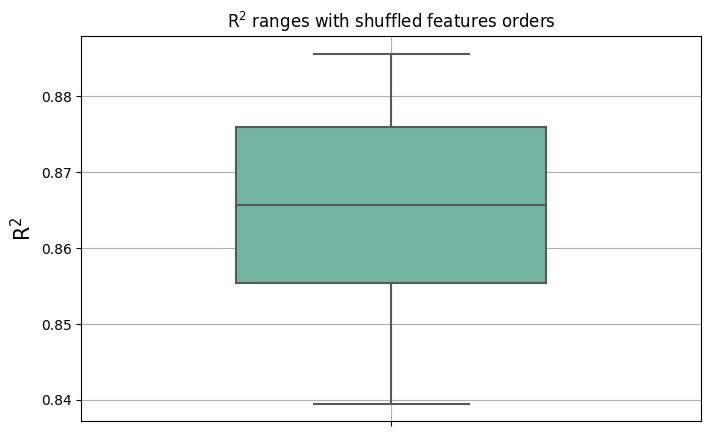

In [40]:
plt.figure(figsize=(8,5))
sns.boxplot(
    paras['r2'],
    showfliers=True,    
    palette="Set2",
    width=0.5,
    linewidth=1.5
)
plt.xlabel("", fontsize=15)
plt.ylabel("R$^2$", fontsize=15)
plt.grid()
plt.title("R$^2$ ranges with shuffled features orders")
plt.savefig('../results/figures/mix/r_square_shuffle.png')